# Benchmarking Your Spectral Function Against MaxEnt

This notebook compares any spectral function $A(\omega)$ against **Maximum Entropy (MaxEnt)** analytic continuation using [`ana_cont`](https://github.com/josefkaufmann/ana_cont) (Kaufmann & Held, CPC 2022).

---

## Setup — do this once before opening the notebook

### 1. Download the required folder

The only folder you need from the repository is **`MaxEnt_benchmark/`**. Download or clone it, then open a terminal inside it:

```
MaxEnt_benchmark/
├── benchmark_tutorial.ipynb   ← this notebook
├── ana_cont/                  ← MaxEnt library (must be installed, see below)
├── run_anacont_maxent.py      ← only needed if you want to re-run MaxEnt yourself
└── out/                       ← optional: pre-computed MaxEnt .npz results
```

### 2. Install dependencies

From inside the `MaxEnt_benchmark/` folder (or from the repo root), run:

```bash
# Core scientific stack
pip install numpy scipy matplotlib

# Only needed if you load a PyTorch summary.pt file:
pip install torch

# ana_cont — the MaxEnt library bundled in this folder.
# Must be installed before the notebook will run.
pip install cython          # required build dependency
pip install -e ana_cont/    # installs ana_cont in editable mode
```

> **Tip:** If you are using a virtual environment or conda, activate it first, then run the commands above inside it.

### 3. Open the notebook

```bash
jupyter notebook benchmark_tutorial.ipynb
# or
jupyter lab benchmark_tutorial.ipynb
```

Select the kernel that matches your environment (the one where you ran `pip install` above).

---

## What is required vs optional

| Input | Required? | Used for |
|---|---|---|
| Your $A(\omega)$ | **Yes** | The method you want to benchmark |
| DQMC bins `Gbins_*.csv` | Optional | Running MaxEnt from scratch |
| Pre-computed MaxEnt `.npz` | Optional | Load a previous MaxEnt run instead of re-running |
| Ground truth `spectral_input.csv` | Optional | $L^2$/$L^\infty$ error metrics |
| `summary.pt` | Optional | Load G(\u03c4) inputs/recons and per-sample $A(\omega)$ from a PyTorch VAE |
| G(\u03c4) input CSV / array | Optional | G(\u03c4) comparison plot — **alternative to** `summary.pt` |
| G(\u03c4) reconstruction CSV / array | Optional | G(\u03c4) comparison plot — **alternative to** `summary.pt` |
| Per-sample $A(\omega)$ CSV / array | Optional | Per-sample spectral plot — **alternative to** `summary.pt` |

**At minimum:** provide your $A(\omega)$ and $\omega$ grid in the Configuration cell. Everything else is optional.


In [1]:
import os, sys, subprocess, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({"font.size": 12, "axes.labelsize": 13, "figure.dpi": 110})

# Paths so the existing scripts can be imported / called
NOTEBOOK_DIR = os.path.abspath('')
PROJ_ROOT    = os.path.dirname(NOTEBOOK_DIR)
ANACONT_DIR  = os.path.join(NOTEBOOK_DIR, 'ana_cont')
sys.path.insert(0, PROJ_ROOT)
sys.path.insert(0, ANACONT_DIR)

print('Environment ready.')

Environment ready.


---
## Configuration

### Required: your spectral function

Set `YOUR_OMEGA` and `YOUR_A` to your $\omega$ grid and $A(\omega)$ values.  
Three loading options are shown; uncomment the one that fits your workflow.

In [2]:
# ================================================================
# REQUIRED — your spectral function
# ================================================================
# Choose ONE of the three options below.

# --- Option A: load from a VAE summary.pt ---
VAE_SUMMARY_PATH = "/Users/georgeissa/Documents/AC/SPE-AC-VAE/out/" \
                   "finetune_gaussian_double_numpoles6_s1e-04_xi0.5-fresh-v2L-2/summary.pt"

if os.path.exists(VAE_SUMMARY_PATH):
    import torch
    _s        = torch.load(VAE_SUMMARY_PATH, weights_only=False)
    YOUR_OMEGA = _s['omega_eval_grid'].numpy()        # (N_omega,)
    YOUR_A     = _s['A_mean'].numpy().mean(axis=0)    # (N_omega,)  — dataset average
    # To show per-sample spectra instead of the average, replace the line above with:
    #   YOUR_A_all = _s['A_mean'].numpy()             # (N_samples, N_omega)
    print(f'Loaded from summary.pt: {len(YOUR_OMEGA)} omega points, '
          f'omega in [{YOUR_OMEGA[0]:.1f}, {YOUR_OMEGA[-1]:.1f}]')
else:
    print('summary.pt not found — using Option B or C below.')
    YOUR_OMEGA = None
    YOUR_A     = None

# --- Option B: load from a numpy / CSV file ---
# YOUR_OMEGA = np.linspace(-8, 8, 500)                     # your omega grid
# YOUR_A     = np.loadtxt('path/to/your_A_omega.csv')      # 1-D array

# --- Option C: define directly as a numpy array ---
# YOUR_OMEGA = np.linspace(-8, 8, 500)
# YOUR_A     = <your array here>

Loaded from summary.pt: 500 omega points, omega in [-8.0, 8.0]


In [3]:
# ================================================================
# OPTIONAL — DQMC data for running MaxEnt
# ================================================================
# Set to None to skip MaxEnt entirely.

MAIN_PATH = "/Users/georgeissa/Documents/AC/SPE-AC-VAE"

DATA_PATH = os.path.join(
    MAIN_PATH, "Data", "datasets",
    "half-filled-gaussian_double", "inputs-8",
    "Gbins_s1e-04_xi0.5.csv"
)
# DATA_PATH = None   # ← uncomment to skip MaxEnt

# Physical parameters — must match your dataset
BETA = 10.0
DTAU = 0.05

# ================================================================
# OPTIONAL — pre-computed MaxEnt results (skip re-running)
# ================================================================
# If these files exist they are loaded directly; MaxEnt is NOT re-run.
# Set to None to always re-run.

_ME_DIR = os.path.join(MAIN_PATH, "MaxEnt_benchmark", "out",
                        "anacont_gaussian_double_inputs-8_s1e-04")
MAXENT_DIAG_NPZ    = os.path.join(_ME_DIR, "summary_mean.npz")
MAXENT_FULLCOV_NPZ = os.path.join(_ME_DIR, "summary_mean_fullcov.npz")
# MAXENT_DIAG_NPZ    = None
# MAXENT_FULLCOV_NPZ = None

# ================================================================
# OPTIONAL — ground truth
# ================================================================
# Set to None if you don't have a reference spectrum.

SPECTRAL_INPUT_PATH = os.path.join(
    MAIN_PATH, "Data", "datasets",
    "half-filled-gaussian_double", "inputs-8",
    "spectral_input.csv"
)
# SPECTRAL_INPUT_PATH = None

# ================================================================
# OPTIONAL — G(tau) inputs and reconstructions
# ================================================================
# Used in Step 7 (G(tau) comparison plot).
# Three ways to provide this data — use whichever fits your workflow:
#
#   Option A: PyTorch summary.pt  (loaded automatically in Step 7 if it exists)
VAE_SUMMARY_PATH = os.path.join(
    MAIN_PATH, "out",
    "finetune_gaussian_double_numpoles6_s1e-04_xi0.5-fresh-v2L-2",
    "summary.pt"
)
# VAE_SUMMARY_PATH = None   # ← set to None if you don't have summary.pt
#
#   Option B: CSV / numpy files
#     Shape: (N_samples, L_tau) — one row per sample
#     Or:    (L_tau,)           — just the mean curve
#     The tau grid is built from BETA and DTAU above.
GTAU_INPUT_PATH = None   # e.g. "path/to/G_input.csv"
GTAU_RECON_PATH = None   # e.g. "path/to/G_recon.csv"
#
#   Option C: numpy arrays defined directly in this cell
GTAU_INPUT_ARRAY = None  # np.ndarray, shape (N_samples, L_tau) or (L_tau,)
GTAU_RECON_ARRAY = None  # np.ndarray, shape (N_samples, L_tau) or (L_tau,)

# ================================================================
# OPTIONAL — per-sample A(omega) arrays
# ================================================================
# Used in Step 6 (per-sample spectral plot).
# Three ways to provide this data:
#
#   Option A: PyTorch summary.pt  (loaded automatically in Step 6 if it exists)
#             (same VAE_SUMMARY_PATH as above)
#
#   Option B: CSV / numpy file
#     Shape: (N_samples, N_omega)
#     The omega grid is taken from YOUR_OMEGA defined in the cell above.
A_ALL_PATH = None   # e.g. "path/to/A_all.csv"
#
#   Option C: numpy array defined directly
A_ALL_ARRAY = None  # np.ndarray, shape (N_samples, N_omega)

# ================================================================
# Real-frequency grid and MaxEnt solver settings
# (only used if MaxEnt is re-run)
# ================================================================
OMEGA_MIN   = -8.0
OMEGA_MAX   =  8.0
N_OMEGA     =  500
ALPHA_START = 1e12
ALPHA_END   = 1e-2

print('Configuration set.')

Configuration set.


---
## Step 1 — Verify your spectral function

omega: [-8.00, 8.00]  (500 points)
A(omega): min=-0.0010, max=0.4811
Norm  ∫A dω = 1.0037  (fermionic sum rule: should be ~1.0)


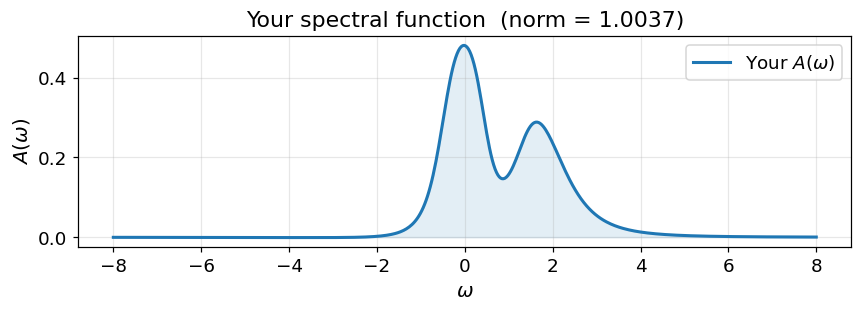

In [4]:
assert YOUR_OMEGA is not None and YOUR_A is not None, \
    "Set YOUR_OMEGA and YOUR_A in the Configuration cell above."
assert YOUR_OMEGA.shape == YOUR_A.shape, \
    f"Shape mismatch: omega {YOUR_OMEGA.shape} vs A {YOUR_A.shape}"

norm = float(np.trapz(YOUR_A, YOUR_OMEGA))
print(f'omega: [{YOUR_OMEGA[0]:.2f}, {YOUR_OMEGA[-1]:.2f}]  ({len(YOUR_OMEGA)} points)')
print(f'A(omega): min={YOUR_A.min():.4f}, max={YOUR_A.max():.4f}')
print(f'Norm  ∫A dω = {norm:.4f}  (fermionic sum rule: should be ~1.0)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(YOUR_OMEGA, YOUR_A, color='tab:blue', lw=2, label='Your $A(\\omega)$')
ax.fill_between(YOUR_OMEGA, YOUR_A, alpha=0.12, color='tab:blue')
ax.set_xlabel(r'$\omega$')
ax.set_ylabel(r'$A(\omega)$')
ax.set_title(f'Your spectral function  (norm = {norm:.4f})')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 2 — Load ground truth *(optional)*

In [5]:
if SPECTRAL_INPUT_PATH and os.path.exists(str(SPECTRAL_INPUT_PATH)):
    A_gt     = np.loadtxt(SPECTRAL_INPUT_PATH, delimiter=',')
    omega_gt = np.linspace(-5.0, 5.0, len(A_gt))
    print(f'Ground truth loaded: {len(A_gt)} points, '
          f'omega in [{omega_gt[0]:.1f}, {omega_gt[-1]:.1f}]')
else:
    A_gt = omega_gt = None
    print('No ground truth; error metrics will be skipped.')

Ground truth loaded: 1000 points, omega in [-5.0, 5.0]


---
## Step 3 — Load or run MaxEnt *(optional)*

MaxEnt recovers $A(\omega)$ from $G(\tau)$ by solving the Fredholm equation:
$$G(\tau) = \int K(\tau,\omega)\,A(\omega)\,d\omega, \qquad K(\tau,\omega) = \frac{e^{-\tilde\tau\,\omega}}{1+e^{-\omega}}$$

The ill-posed inversion is regularized by maximizing the Shannon entropy of $A$ relative to a flat default model, with regularization strength $\alpha$ chosen automatically via the **chi2kink** criterion.

Two variants are run:
- **Diagonal $C$**: uses only the per-point SEM; standard workflow
- **Full $C$**: passes the complete $(L_\tau \times L_\tau)$ covariance matrix; accounts for correlated noise

In [6]:
import ana_cont.continuation as cont

def regularize_cov(C, rcond=1e-6):
    """Floor near-zero eigenvalues to prevent blow-up when inverting C."""
    evals, evecs = np.linalg.eigh(C)
    floor = evals.max() * rcond
    n_floored = int((evals < floor).sum())
    if n_floored:
        print(f'  Regularizing covariance: flooring {n_floored} eigenvalue(s) '
              f'below {floor:.2e}')
    return evecs @ np.diag(np.maximum(evals, floor)) @ evecs.T


def run_maxent_once(tau, omega, G_mean, beta,
                    err=None, cov=None,
                    alpha_start=1e12, alpha_end=1e-2):
    """Run ana_cont MaxEnt for a single mean G(tau).

    Pass exactly one of `err` (diagonal SEM array) or `cov` (full covariance matrix).
    Returns: A_opt (N_omega,), chi2 (float), backtransform (L_tau,)
    """
    model = np.ones_like(omega)
    model /= np.trapz(model, omega)     # flat default model, norm = 1

    probl = cont.AnalyticContinuationProblem(
        im_axis=tau, re_axis=omega, im_data=G_mean,
        kernel_mode='time_fermionic', beta=beta,
    )
    kwargs = dict(
        method='maxent_svd', alpha_determination='chi2kink',
        optimizer='newton', model=model,
        interactive=False,
        alpha_start=alpha_start, alpha_end=alpha_end,
    )
    kwargs['cov' if cov is not None else 'stdev'] = cov if cov is not None else err
    sol, _ = probl.solve(**kwargs)
    return sol.A_opt, float(sol.chi2), sol.backtransform

In [7]:
me_diag = me_full = None   # will be filled below if available

# --- Try to load pre-computed results first ---
if MAXENT_DIAG_NPZ and os.path.exists(str(MAXENT_DIAG_NPZ)):
    me_diag = dict(np.load(MAXENT_DIAG_NPZ, allow_pickle=True))
    print(f'Loaded MaxEnt (diag C):     chi2={float(me_diag["chi2"]):.1f},  '
          f'norm={np.trapz(me_diag["A_opt"], me_diag["omega"]):.4f}')

if MAXENT_FULLCOV_NPZ and os.path.exists(str(MAXENT_FULLCOV_NPZ)):
    me_full = dict(np.load(MAXENT_FULLCOV_NPZ, allow_pickle=True))
    print(f'Loaded MaxEnt (full C):     chi2={float(me_full["chi2"]):.1f},  '
          f'norm={np.trapz(me_full["A_opt"], me_full["omega"]):.4f}')

# --- Run MaxEnt if data is provided and results are missing ---
if DATA_PATH and os.path.exists(str(DATA_PATH)) and (me_diag is None or me_full is None):
    print(f'\nLoading DQMC data from: {DATA_PATH}')
    G_bins = np.loadtxt(DATA_PATH, delimiter=',')
    if G_bins.ndim == 1:
        G_bins = G_bins[np.newaxis, :]
    N_bins, L_tau = G_bins.shape
    tau    = np.linspace(0.0, BETA - DTAU, L_tau)
    omega  = np.linspace(OMEGA_MIN, OMEGA_MAX, N_OMEGA)
    G_mean = G_bins.mean(axis=0)
    dG     = G_bins - G_mean
    C      = (dG.T @ dG) / (N_bins - 1)
    C_mean = C / N_bins
    sem    = np.sqrt(np.diag(C_mean))
    print(f'  {N_bins} bins × {L_tau} τ points,  mean SEM = {sem.mean():.2e}')

    if me_diag is None:
        print('\nRunning MaxEnt (diagonal C) — ~30 s...')
        A_opt, chi2, bt = run_maxent_once(tau, omega, G_mean, BETA,
                                          err=sem,
                                          alpha_start=ALPHA_START,
                                          alpha_end=ALPHA_END)
        me_diag = dict(omega=omega, A_opt=A_opt, chi2=chi2,
                       backtransform=bt, tau=tau, G_mean=G_mean)
        print(f'  chi2={chi2:.1f},  norm={np.trapz(A_opt, omega):.4f}')

    if me_full is None:
        print('\nRunning MaxEnt (full C) — ~30 s...')
        C_reg = regularize_cov(C_mean)
        A_opt, chi2, bt = run_maxent_once(tau, omega, G_mean, BETA,
                                          cov=C_reg,
                                          alpha_start=ALPHA_START,
                                          alpha_end=ALPHA_END)
        me_full = dict(omega=omega, A_opt=A_opt, chi2=chi2,
                       backtransform=bt, tau=tau, G_mean=G_mean)
        print(f'  chi2={chi2:.1f},  norm={np.trapz(A_opt, omega):.4f}')

elif me_diag is None and me_full is None:
    print('No DQMC data and no pre-computed MaxEnt results — MaxEnt will be omitted from plots.')

Loaded MaxEnt (diag C):     chi2=2045.0,  norm=1.0072
Loaded MaxEnt (full C):     chi2=1354.7,  norm=1.0056


---
## Step 4 — Build the methods list

All plots and metrics iterate over this list. Add, remove, or rename entries freely.

In [8]:
# Each entry: (label, omega_array, A_array, color, linestyle)
# Remove an entry or set it to None to skip it.

METHODS = [
    ('SPE-AC-VAE',           YOUR_OMEGA,                  YOUR_A,      'tab:blue',   '-'),
    
    ('MaxEnt (diag $C$)',     me_diag['omega'] if me_diag else None,
                              me_diag['A_opt'] if me_diag else None,  'tab:orange', '--'),
    
    ('MaxEnt (full $C$)',     me_full['omega'] if me_full else None,
                              me_full['A_opt'] if me_full else None,  'tab:red',    '-.'),
]

# Filter out entries that have no data
METHODS = [(lbl, om, A, col, ls)
           for lbl, om, A, col, ls in METHODS
           if om is not None and A is not None]

print('Active methods:')
for lbl, om, A, col, ls in METHODS:
    norm = np.trapz(A, om)
    print(f'  {lbl:<30}  omega=[{om[0]:.1f}, {om[-1]:.1f}]  norm={norm:.4f}')

Active methods:
  SPE-AC-VAE                      omega=[-8.0, 8.0]  norm=1.0037
  MaxEnt (diag $C$)               omega=[-8.0, 8.0]  norm=1.0072
  MaxEnt (full $C$)               omega=[-8.0, 8.0]  norm=1.0056


---
## Step 5 — Spectral function comparison

This is the main comparison plot. It is always produced regardless of which optional inputs were provided.

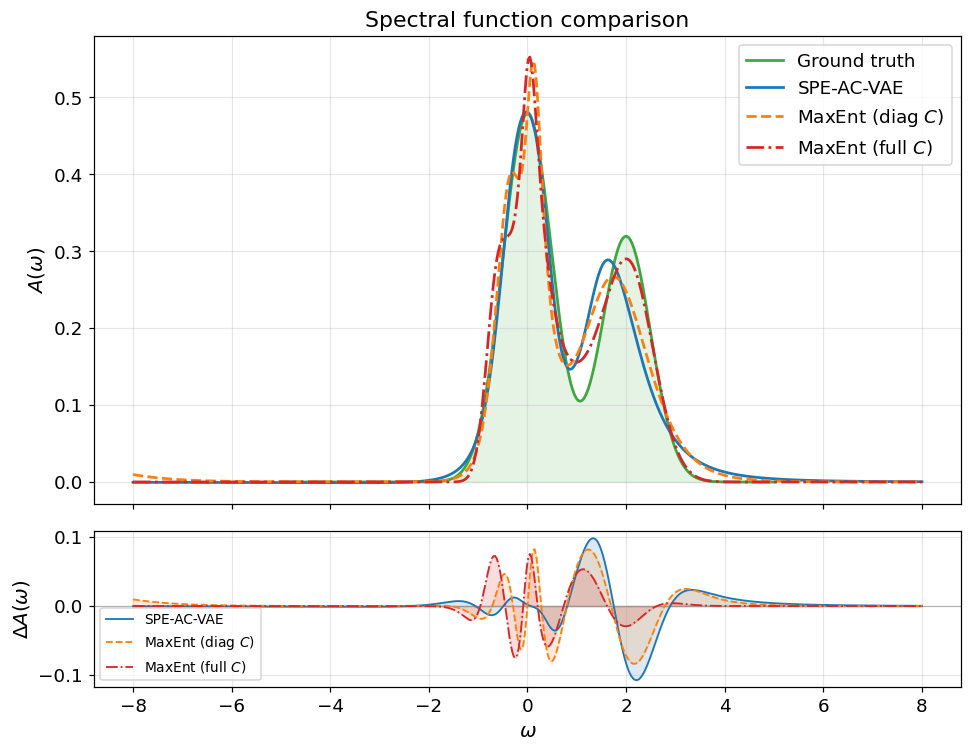

In [9]:
has_gt   = A_gt is not None
n_panels = 2 if has_gt else 1
heights  = [3, 1] if has_gt else [1]

fig, axes = plt.subplots(
    n_panels, 1, figsize=(9, 7 if has_gt else 4),
    gridspec_kw={'height_ratios': heights},
    sharex=True,
)
ax1 = axes[0] if has_gt else axes
ax2 = axes[1] if has_gt else None

# Ground truth
if has_gt:
    ax1.fill_between(omega_gt, A_gt, alpha=0.12, color='tab:green')
    ax1.plot(omega_gt, A_gt, color='tab:green', lw=1.8, alpha=0.9,
             label='Ground truth')

# All methods
for lbl, om, A, col, ls in METHODS:
    ax1.plot(om, A, color=col, lw=1.8, ls=ls, label=lbl)

ax1.set_ylabel(r'$A(\omega)$')
ax1.set_title(r'Spectral function comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Residual panel (only if ground truth is available)
if has_gt and ax2 is not None:
    ax2.axhline(0, color='gray', lw=0.8, alpha=0.5)
    for lbl, om, A, col, ls in METHODS:
        gt_i = np.interp(om, omega_gt, A_gt)
        diff = A - gt_i
        ax2.plot(om, diff, color=col, lw=1.2, ls=ls, label=lbl)
        ax2.fill_between(om, diff, alpha=0.15, color=col)
    ax2.set_ylabel(r'$\Delta A(\omega)$')
    ax2.set_xlabel(r'$\omega$')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
else:
    ax1.set_xlabel(r'$\omega$')

fig.tight_layout()
plt.show()

---
## Step 6 — Per-sample spectra *(optional)*

Shows individual $A(\omega)$ outputs from your method alongside the MaxEnt mean result.

**Three ways to provide per-sample data (set in Configuration):**
- **Option A** — `VAE_SUMMARY_PATH`: loads from a PyTorch `summary.pt` file
- **Option B** — `A_ALL_PATH`: path to a CSV/numpy file of shape `(N_samples, N_omega)`
- **Option C** — `A_ALL_ARRAY`: a numpy array you define directly in the Configuration cell

The $\omega$ grid for Options B and C is taken from `YOUR_OMEGA`.

In [10]:
A_all     = None   # (N_samples, N_omega)
omega_all = None   # (N_omega,)

# Option A — summary.pt
if A_all is None and VAE_SUMMARY_PATH and os.path.exists(str(VAE_SUMMARY_PATH)):
    try:
        import torch
        _s        = torch.load(VAE_SUMMARY_PATH, weights_only=False)
        A_all     = _s['A_mean'].numpy()
        omega_all = _s['omega_eval_grid'].numpy()
        print(f'Per-sample A(omega) loaded from summary.pt: '
              f'{A_all.shape[0]} samples × {A_all.shape[1]} omega points')
    except Exception as e:
        print(f'Could not load summary.pt: {e}')

# Option B — CSV / numpy file
if A_all is None and A_ALL_PATH and os.path.exists(str(A_ALL_PATH)):
    A_all     = np.loadtxt(A_ALL_PATH, delimiter=',')
    if A_all.ndim == 1:
        A_all = A_all[np.newaxis, :]
    omega_all = YOUR_OMEGA
    print(f'Per-sample A(omega) loaded from file: '
          f'{A_all.shape[0]} samples × {A_all.shape[1]} omega points')

# Option C — numpy array
if A_all is None and A_ALL_ARRAY is not None:
    A_all = np.atleast_2d(A_ALL_ARRAY)
    omega_all = YOUR_OMEGA
    print(f'Per-sample A(omega) from array: '
          f'{A_all.shape[0]} samples × {A_all.shape[1]} omega points')

if A_all is None:
    print('No per-sample A(omega) provided — Step 6 plot will be skipped.')

Per-sample A(omega) loaded from summary.pt: 1000 samples × 500 omega points


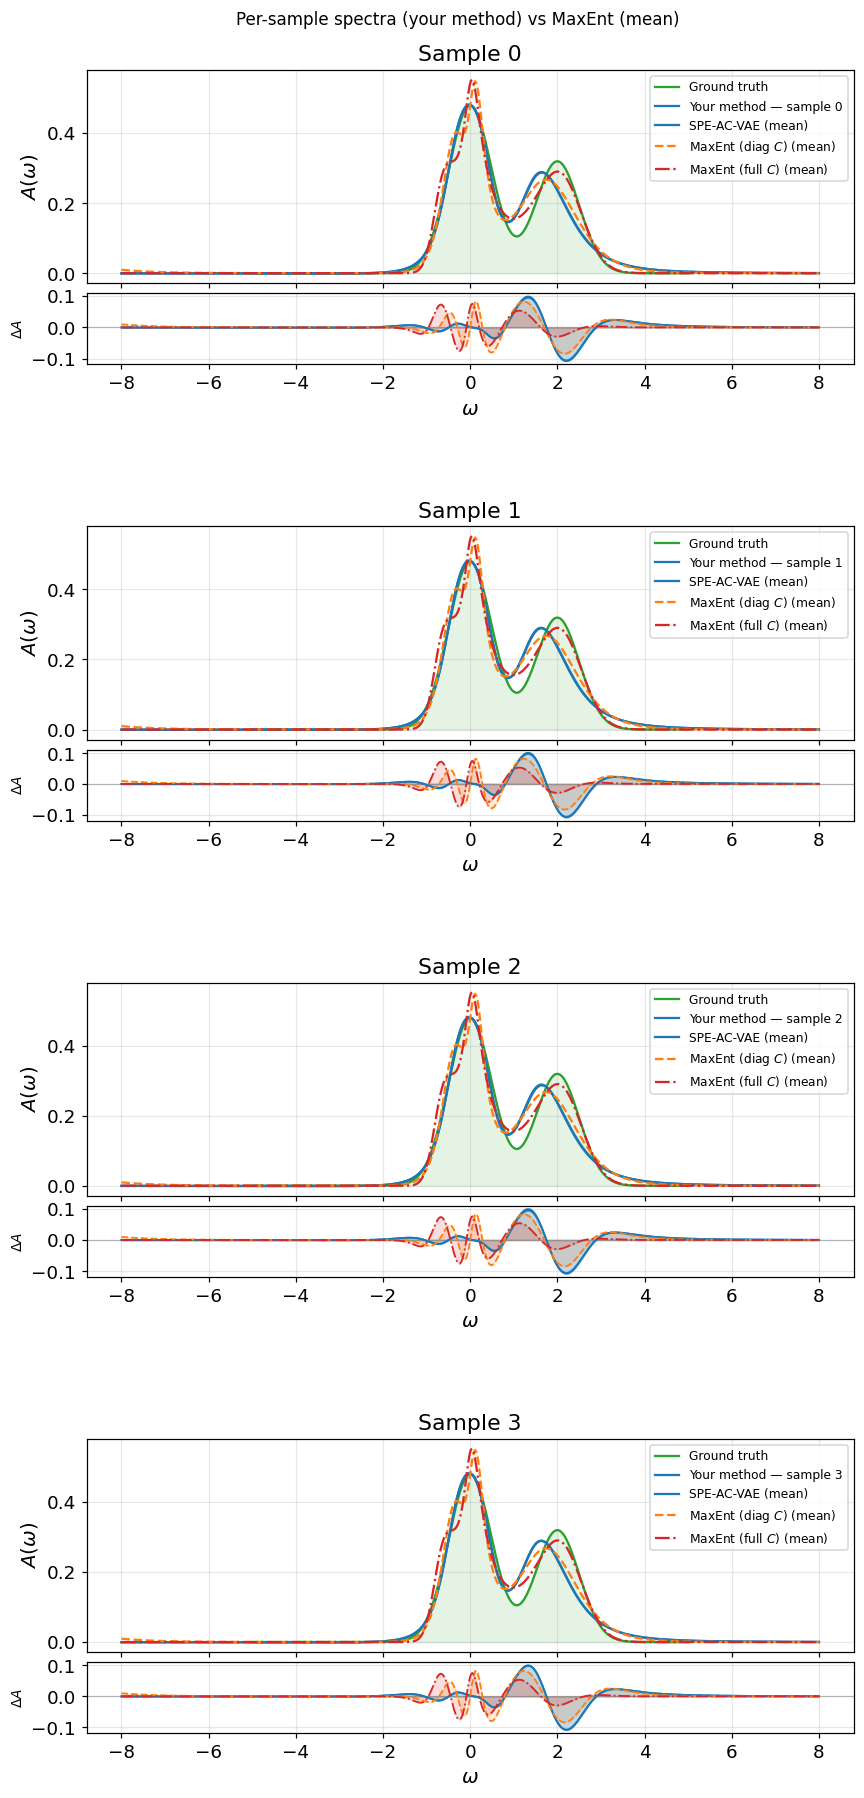

In [11]:
if A_all is not None:
    SAMPLE_INDICES = [0, 1, 2, 3]
    n_panels = len(SAMPLE_INDICES)

    fig = plt.figure(figsize=(9, 4.5 * n_panels))
    outer = gridspec.GridSpec(n_panels, 1, figure=fig, hspace=0.55)

    for row, idx in enumerate(SAMPLE_INDICES):
        if idx >= A_all.shape[0]:
            print(f'Sample {idx} out of range ({A_all.shape[0]} samples) — skipping.')
            continue
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[row], height_ratios=[3, 1], hspace=0.07
        )
        ax_main = fig.add_subplot(inner[0])
        ax_diff = fig.add_subplot(inner[1], sharex=ax_main)

        if has_gt:
            ax_main.fill_between(omega_gt, A_gt, alpha=0.12, color='tab:green')
            ax_main.plot(omega_gt, A_gt, color='tab:green', lw=1.5, label='Ground truth')

        ax_main.plot(omega_all, A_all[idx], color='tab:blue', lw=1.5,
                     label=f'Your method — sample {idx}')

        for lbl, om, A, col, ls in METHODS:
            if lbl != 'Your method':
                ax_main.plot(om, A, color=col, lw=1.5, ls=ls, label=f'{lbl} (mean)')

        ax_main.set_ylabel(r'$A(\omega)$')
        ax_main.set_title(f'Sample {idx}')
        ax_main.legend(fontsize=8)
        ax_main.grid(True, alpha=0.3)
        plt.setp(ax_main.get_xticklabels(), visible=False)

        ax_diff.axhline(0, color='gray', lw=0.8, alpha=0.5)
        if has_gt:
            gt_v = np.interp(omega_all, omega_gt, A_gt)
            dv   = A_all[idx] - gt_v
            ax_diff.plot(omega_all, dv, color='tab:blue', lw=1.2)
            ax_diff.fill_between(omega_all, dv, alpha=0.15, color='tab:blue')
            for lbl, om, A, col, ls in METHODS:
                if lbl != 'Your method':
                    gt_m = np.interp(om, omega_gt, A_gt)
                    dm   = A - gt_m
                    ax_diff.plot(om, dm, color=col, lw=1.2, ls=ls)
                    ax_diff.fill_between(om, dm, alpha=0.15, color=col)
        ax_diff.set_ylabel(r'$\Delta A$', fontsize=9)
        ax_diff.set_xlabel(r'$\omega$')
        ax_diff.grid(True, alpha=0.3)

    fig.suptitle('Per-sample spectra (your method) vs MaxEnt (mean)', fontsize=11)
    fig.subplots_adjust(top=0.95)
    plt.show()
else:
    print('Skipped (no per-sample data).')

---
## Step 7 — G(τ) reconstruction *(optional)*

Overlays the original G(τ) data, your model's reconstruction, and the MaxEnt back-transform.  
If only the input is provided (no reconstruction), the plot still runs — useful for comparing MaxEnt directly against the data.

**Three ways to provide G(τ) data (set in Configuration):**
- **Option A** — `VAE_SUMMARY_PATH`: loads `inputs` and `recon` arrays from a PyTorch `summary.pt`
- **Option B** — `GTAU_INPUT_PATH` / `GTAU_RECON_PATH`: paths to CSV/numpy files, shape `(N_samples, L_tau)` or `(L_tau,)`
- **Option C** — `GTAU_INPUT_ARRAY` / `GTAU_RECON_ARRAY`: numpy arrays defined directly in Configuration

The reconstruction (`GTAU_RECON_*`) is optional — if omitted the plot shows input vs MaxEnt back-transform only.

In [12]:
G_input_all = None   # (N_samples, L_tau) or (L_tau,)
G_recon_all = None   # (N_samples, L_tau) or (L_tau,) — optional
tau_gtau    = None   # (L_tau,)

def _load_gtau_array(path_or_array):
    """Load a G(tau) array from a file path or return it directly."""
    if isinstance(path_or_array, np.ndarray):
        return path_or_array
    if path_or_array and os.path.exists(str(path_or_array)):
        arr = np.loadtxt(path_or_array, delimiter=',')
        return arr
    return None

# Option A — summary.pt
if G_input_all is None and VAE_SUMMARY_PATH and os.path.exists(str(VAE_SUMMARY_PATH)):
    try:
        import torch
        _s          = torch.load(VAE_SUMMARY_PATH, weights_only=False)
        G_input_all = _s['inputs'].numpy()
        G_recon_all = _s['recon'].numpy()
        tau_gtau    = np.linspace(0, float(_s['beta']), int(_s['Ltau']))
        print(f'G(tau) loaded from summary.pt: '
              f'{G_input_all.shape[0]} samples × {G_input_all.shape[1]} tau points')
    except Exception as e:
        print(f'Could not load summary.pt: {e}')

# Option B — CSV / numpy files
if G_input_all is None:
    _inp = _load_gtau_array(GTAU_INPUT_PATH)
    if _inp is not None:
        G_input_all = np.atleast_2d(_inp)
        _L = G_input_all.shape[1]
        tau_gtau = np.linspace(0.0, BETA - DTAU, _L)
        print(f'G(tau) input loaded from file: shape {G_input_all.shape}')
    _rec = _load_gtau_array(GTAU_RECON_PATH)
    if _rec is not None:
        G_recon_all = np.atleast_2d(_rec)
        print(f'G(tau) recon loaded from file:  shape {G_recon_all.shape}')

# Option C — numpy arrays
if G_input_all is None and GTAU_INPUT_ARRAY is not None:
    G_input_all = np.atleast_2d(GTAU_INPUT_ARRAY)
    _L = G_input_all.shape[1]
    tau_gtau = np.linspace(0.0, BETA - DTAU, _L)
    print(f'G(tau) input from array: shape {G_input_all.shape}')
if G_recon_all is None and GTAU_RECON_ARRAY is not None:
    G_recon_all = np.atleast_2d(GTAU_RECON_ARRAY)
    print(f'G(tau) recon from array: shape {G_recon_all.shape}')

# Summary
has_maxent = me_diag is not None or me_full is not None
can_plot_gtau = G_input_all is not None and (has_maxent or G_recon_all is not None)

if not can_plot_gtau:
    if G_input_all is None:
        print('No G(tau) input provided — Step 7 skipped.')
    else:
        print('G(tau) input found but no MaxEnt or reconstruction to compare against — Step 7 skipped.')
else:
    n_r = G_recon_all.shape[0] if G_recon_all is not None else 0
    print(f'Ready to plot: {G_input_all.shape[0]} input samples'
          + (f', {n_r} recon samples' if G_recon_all is not None else ', no recon')
          + (', MaxEnt back-transforms available' if has_maxent else ''))

G(tau) loaded from summary.pt: 1000 samples × 200 tau points
Ready to plot: 1000 input samples, 1000 recon samples, MaxEnt back-transforms available


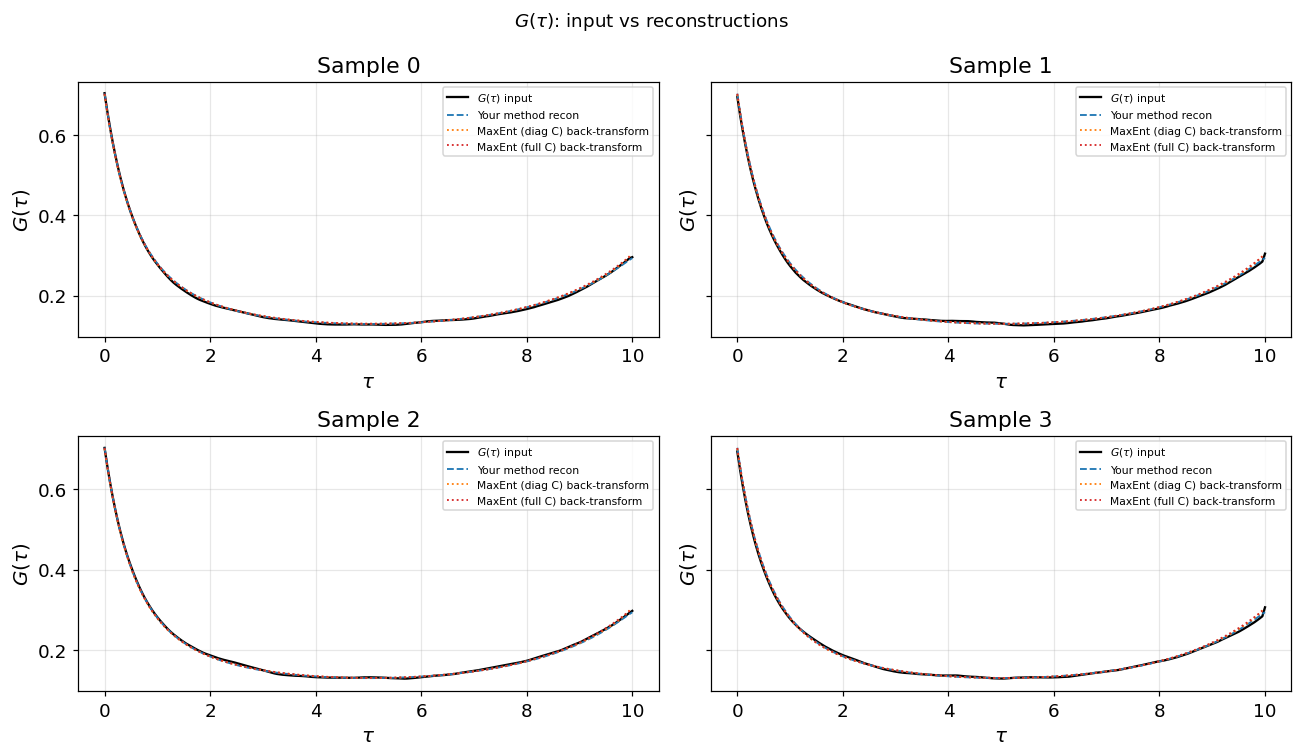

In [13]:
if can_plot_gtau:
    SAMPLE_INDICES_GTAU = [0, 1, 2, 3]
    # Only keep indices that exist in G_input_all
    valid_idx = [i for i in SAMPLE_INDICES_GTAU if i < G_input_all.shape[0]]
    n_plots   = len(valid_idx)
    ncols     = min(2, n_plots)
    nrows     = (n_plots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 3.5 * nrows),
                             sharey=True, squeeze=False)

    for plot_i, idx in enumerate(valid_idx):
        ax = axes[plot_i // ncols][plot_i % ncols]

        # Input G(tau)
        ax.plot(tau_gtau, G_input_all[idx], 'k-', lw=1.5,
                label=r'$G(\tau)$ input')

        # Model reconstruction (if available)
        if G_recon_all is not None and idx < G_recon_all.shape[0]:
            ax.plot(tau_gtau, G_recon_all[idx], color='tab:blue', lw=1.2, ls='--',
                    label='Your method recon')

        # MaxEnt back-transforms
        if me_diag is not None:
            ax.plot(me_diag['tau'], me_diag['backtransform'],
                    color='tab:orange', lw=1.2, ls=':',
                    label='MaxEnt (diag C) back-transform')
        if me_full is not None:
            ax.plot(me_full['tau'], me_full['backtransform'],
                    color='tab:red', lw=1.2, ls=':',
                    label='MaxEnt (full C) back-transform')

        ax.set_title(f'Sample {idx}')
        ax.set_xlabel(r'$\tau$')
        ax.set_ylabel(r'$G(\tau)$')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    # Hide any unused subplots
    for plot_i in range(len(valid_idx), nrows * ncols):
        axes[plot_i // ncols][plot_i % ncols].set_visible(False)

    fig.suptitle(r'$G(\tau)$: input vs reconstructions', fontsize=12)
    fig.tight_layout()
    plt.show()
else:
    print('Skipped.')

---
## Step 8 — Metrics table *(optional — requires ground truth)*

| Metric | Formula | Meaning |
|---|---|---|
| **Norm** | $\int A\,d\omega$ | Fermionic sum rule should equal 1 |
| **$L^2$ error** | $\sqrt{\int (A-A_{\rm gt})^2\,d\omega}$ | Overall shape error |
| **$L^\infty$ error** | $\max_\omega \|A-A_{\rm gt}\|$ | Worst-case peak error |

In [14]:
rows = []
for lbl, om, A, col, ls in METHODS:
    norm = float(np.trapz(A, om))
    if has_gt:
        gt_i = np.interp(om, omega_gt, A_gt)
        l2   = float(np.sqrt(np.trapz((A - gt_i)**2, om)))
        linf = float(np.max(np.abs(A - gt_i)))
    else:
        l2 = linf = float('nan')
    rows.append((lbl, norm, l2, linf))

print(f'{"Method":<30} {"Norm":>8} {"L2 err":>10} {"Linf err":>10}')
print('=' * 60)
for lbl, norm, l2, linf in rows:
    l2_s   = f'{l2:.5f}'   if not np.isnan(l2)   else '      n/a'
    linf_s = f'{linf:.5f}' if not np.isnan(linf) else '      n/a'
    print(f'{lbl:<30} {norm:>8.4f} {l2_s:>10} {linf_s:>10}')

Method                             Norm     L2 err   Linf err
SPE-AC-VAE                       1.0037    0.10662    0.10733
MaxEnt (diag $C$)                1.0072    0.10402    0.08373
MaxEnt (full $C$)                1.0056    0.07589    0.07548


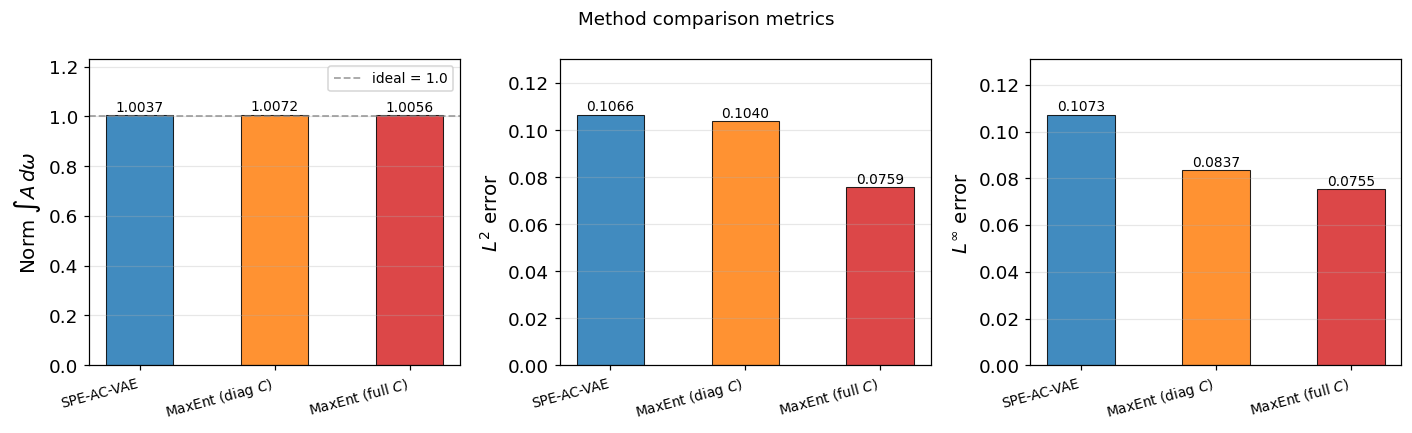

In [15]:
labels_bar = [r[0] for r in rows]
norms_bar  = [r[1] for r in rows]
l2s_bar    = [r[2] for r in rows]
linfs_bar  = [r[3] for r in rows]
colors_bar = [col for _, _, _, col, _ in METHODS]

x = np.arange(len(rows))

# Decide how many panels to show
panels = [('Norm $\\int A\\,d\\omega$', norms_bar, 1.0)]
if has_gt:
    panels += [('$L^2$ error', l2s_bar, None),
               ('$L^\\infty$ error', linfs_bar, None)]

fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels) + 1, 4))
if len(panels) == 1:
    axes = [axes]

for ax, (title, values, hline) in zip(axes, panels):
    valid = [v for v in values if not np.isnan(v)]
    bars  = ax.bar(x, values, color=colors_bar, width=0.5, alpha=0.85,
                   edgecolor='black', linewidth=0.7)
    if hline is not None:
        ax.axhline(hline, color='gray', lw=1.2, ls='--', alpha=0.7,
                   label=f'ideal = {hline}')
        ax.legend(fontsize=9)
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002 * max(valid),
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_bar, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)
    if valid:
        ax.set_ylim(0, max(valid) * 1.22)

fig.suptitle('Method comparison metrics', fontsize=12)
fig.tight_layout()
plt.show()

---
## Summary

**Step 5 (A(ω) comparison) always runs** — it is the minimum output.  
All other steps are opt-in based on what you provide.

| Step | Requires |
|---|---|
| 5 — A(ω) comparison | `YOUR_OMEGA`, `YOUR_A` only |
| 6 — Per-sample spectra | Any one of: `VAE_SUMMARY_PATH`, `A_ALL_PATH`, `A_ALL_ARRAY` |
| 7 — G(τ) reconstruction | G(τ) input (any option) **+** MaxEnt result or G(τ) recon |
| 8 — Metrics | Norm: always. L2/L∞: only if ground truth is provided |

**To adapt this notebook for your method:**

1. **Required:** set `YOUR_OMEGA` and `YOUR_A` in the Configuration cell (Options A, B, or C).

2. **To run MaxEnt:** set `DATA_PATH` to your `Gbins_*.csv` and match `BETA`/`DTAU`.  
   Or point `MAXENT_DIAG_NPZ` / `MAXENT_FULLCOV_NPZ` to pre-computed results.

3. **For per-sample spectra (Step 6):** provide per-sample A(ω) via one of:
   - `VAE_SUMMARY_PATH` — PyTorch `.pt` file with an `A_mean` key
   - `A_ALL_PATH` — CSV file of shape `(N_samples, N_omega)`
   - `A_ALL_ARRAY` — numpy array defined directly

4. **For G(τ) plots (Step 7):** provide G(τ) inputs and/or reconstructions via one of:
   - `VAE_SUMMARY_PATH` — PyTorch `.pt` file with `inputs` and `recon` keys
   - `GTAU_INPUT_PATH` / `GTAU_RECON_PATH` — CSV files, shape `(N_samples, L_tau)` or `(L_tau,)`
   - `GTAU_INPUT_ARRAY` / `GTAU_RECON_ARRAY` — numpy arrays defined directly
   - The reconstruction is optional — the plot runs with just the input.

5. **To add another method** to the A(ω) comparison, append to `METHODS` in Step 4:
   ```python
   ('My other method', omega_array, A_array, 'tab:purple', ':')
   ```